# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load environment variables
# .env file in the current directory
%load_ext dotenv
%dotenv

In [2]:
# Standard library imports: general utilities and path setup
import os                                               # Operating system interfaces
import sys                                              # System-specific parameters and functions

# Third-party imports: data science stack and scikit-learn tooling
import joblib                                           # For model serialization
import numpy as np                                      # Numerical computing
import pandas as pd                                     # Data manipulation
import shap                                             # SHAP for model interpretability

from sklearn.compose import ColumnTransformer           # For feature-specific preprocessing
from sklearn.ensemble import RandomForestRegressor      # Random forest model
from sklearn.linear_model import Lasso, Ridge           # Linear models with regularization
from sklearn.metrics import (                           # Scikit-learn metrics          
    make_scorer,                                        # Custom scoring functions
    mean_absolute_error,                                # MAE metric          
    mean_squared_error,                                 # MSE metric
    r2_score,                                           # R^2 metric
)
from sklearn.model_selection import (                   # Model selection and evaluation
    GridSearchCV,                                       # Hyperparameter tuning
    cross_val_score,                                    # Cross-validation scoring
    cross_validate,                                     # Cross-validation with multiple metrics
    train_test_split,                                   # Train-test splitting
)
from sklearn.pipeline import Pipeline                  # Pipeline for chaining preprocessing and modeling   
from sklearn.preprocessing import (                    # Data preprocessing
    FunctionTransformer,                               # Custom preprocessing functions
    OneHotEncoder,                                     # Categorical encoding
    RobustScaler,                                      # Robust scaling
    StandardScaler,                                    # Standard scaling
)


# Get paths from environment variables
sys.path.append(os.getenv("SRC_DIR"))

# Importing a custom logger from the utils module to log important information.
from utils.logger import get_logger
_logs = get_logger(__name__)

# Load the dataset
ft_path = os.getenv("FOREST_FIRE_DATA")
df_raw = pd.read_csv(ft_path)


/opt/anaconda3/envs/dsi_participant/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load data
# Define ordered column names to enforce consistent schema (overrides original file header)
# Note: See Variable Descriptions in the dataset documentation for details
# https://archive.ics.uci.edu/ml/datasets/Forest+Fires
columns = [
    'coord_x', 'coord_y',          # Spatial coordinates (integers 1–9 / 2–9)
    'month', 'day',                # Categorical: month abbreviation, day of week
    'ffmc', 'dmc', 'dc', 'isi',    # Fire Weather Index subcomponents (continuous)
    'temp', 'rh', 'wind', 'rain',  # Meteorological variables
    'area'                         # Target: burned area (hectares)
]

# Read the raw CSV:
# - header=0 reads the first line (original names) but they are replaced by 'columns'
# - names=columns ensures consistent snake_case naming initialize above
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))

# Observe the data structure
fires_dt.info()

# Log the completion of data loading and feature creation.
_logs.info("Loaded forest fire dataset into DataFrame.")
_logs.info("Created features for spatial coordinates, month, day, and fire weather indices.")


2025-10-04 14:32:32,008, 3534404334.py, 22, INFO, Loaded forest fire dataset into DataFrame.
2025-10-04 14:32:32,009, 3534404334.py, 23, INFO, Created features for spatial coordinates, month, day, and fire weather indices.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [4]:
# Separating features (X) and target (y):
# - Dropping the target column 'area' from the dataframe for model inputs.
# - Applying log1p (log(1 + x)) to 'area' to reduce right skew and handle zeros safely.
X = fires_dt.drop(columns=['area'])             # Features
y = np.log1p(fires_dt['area'])                  # Target

# Log the separation of features and target variable.
_logs.info("Separated features and target variable. Applied log1p transformation to target.")


2025-10-04 14:32:32,029, 665377658.py, 8, INFO, Separated features and target variable. Applied log1p transformation to target.


In [5]:
# Splitting data into train and test sets:
# - test_size=0.2 keeps 20% for unbiased evaluation
# - random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,              # 20% test dataset
    random_state=21             # With a fixed seed for reproducibility
)

# Log the data splitting completion.
_logs.info("Split data into training and testing sets with 80/20 ratio.")

2025-10-04 14:32:32,163, 3291152179.py, 11, INFO, Split data into training and testing sets with 80/20 ratio.


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [6]:
# Defining feature groups for preprocessing:
# - cat_features: categorical string vars (low cardinality) -> OneHotEncoder
# - num_features: continuous / ordinal numeric vars -> scaled
cat_features = ['month', 'day']  # Month and weekday (string categories)
num_features = [
    'coord_x', 'coord_y',          # Spatial coordinates 
    'ffmc', 'dmc', 'dc', 'isi',    # Fire Weather Index components
    'temp', 'rh', 'wind', 'rain'   # Meteorological measurements
]

# ColumnTransformer:
# - 'num': StandardScaler -> centers & scales numeric features
# - 'cat': OneHotEncoder -> expands categorical levels; handle_unknown='ignore' avoids errors on unseen levels
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# Log the preprocessing pipeline definition.
_logs.info("Defined ColumnTransformer for preprocessing: StandardScaler for numeric features and OneHotEncoder for categorical features.")

2025-10-04 14:32:32,174, 1807948568.py, 22, INFO, Defined ColumnTransformer for preprocessing: StandardScaler for numeric features and OneHotEncoder for categorical features.


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [7]:
# Features to log-transform:
# These numeric features are positively skewed.
# Will use log1p to compress large values and help linear models distance-based methods by reducing heteroscedasticity.
log_transform_vars = ['dc', 'dmc', 'isi']

# Pipeline for the subset of numeric features that require a log transform:
# - log_transform: apply np.log1p (safe for zeros)
# - scale: RobustScaler (less sensitive to outliers than StandardScaler)
num_pipeline_preproc2 = Pipeline([
    ('log_transform', FunctionTransformer(func=np.log1p, validate=False)),
    ('scale', RobustScaler())                                                      
])

# ColumnTransformer for preproc2:
# - 'log_scaled': applying the num_pipeline_preproc2 to selected skewed features
# - 'scaled': applying RobustScaler directly to the remaining numeric features
# - 'cat': one-hot encode categorical variables (drop=None keeps all dummies;
#          handle_unknown='ignore' avoids errors on unseen categories in test data)
preproc2 = ColumnTransformer(
    transformers=[
        ('log_scaled', num_pipeline_preproc2, log_transform_vars),
        ('scaled', RobustScaler(), [f for f in num_features if f not in log_transform_vars]),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# Log the advanced preprocessing pipeline definition.
_logs.info("Defined ColumnTransformer for advanced preprocessing: log1p + RobustScaler for skewed numeric features, RobustScaler for other numeric features, and OneHotEncoder for categorical features.")


2025-10-04 14:32:32,184, 2160558279.py, 28, INFO, Defined ColumnTransformer for advanced preprocessing: log1p + RobustScaler for skewed numeric features, RobustScaler for other numeric features, and OneHotEncoder for categorical features.


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [8]:
# Creating a scoring dictionary for cross_validate / GridSearchCV.
# RMSE = sqrt(MSE); squared=False makes mean_squared_error return RMSE directly.
scoring = {
    'rmse': make_scorer(mean_squared_error, squared=False)
}

# Log the scoring dictionary definition.
_logs.info("Defined scoring dictionary with RMSE metric for model evaluation.")

2025-10-04 14:32:32,192, 3025748200.py, 8, INFO, Defined scoring dictionary with RMSE metric for model evaluation.


In [9]:
# Pipeline A = preproc1 + baseline

# Purpose: Establishing a linear baseline with standardized numeric features and one-hot encoded categoricals.
# Model: Ridge regression (L2 regularization) to mitigate overfitting on small datasets.
# Preprocessing: StandardScaler for numeric features, OneHotEncoder for categorical features.
# Evaluation: 5-fold cross-validation using RMSE to assess predictive performance.
pipe_a = Pipeline([
    ('preprocessing', preproc1),  # ColumnTransformer: StandardScaler (numeric) + OneHotEncoder (categorical)
    ('regressor', Ridge())        # Default alpha=1.0 (will later tune via GridSearch)
])

# Cross-validate using negative MSE.
# The data is split 5 ways. Train on 4 parts, test on 1 part. Repeat 5 times. Each test gives a negative MSE score.
# Steps:
# 1. cross_validate returns one score per fold (negative MSE here).
# 2. Convert to positive MSE by negating.
# 3. Aggregate (mean MSE across folds).
# 4. Take square root to report RMSE (scale is same as target's transformed units: log1p(area)).
cv_results_a = cross_validate(
    pipe_a,
    X, y,
    cv=5,                                   
    scoring='neg_mean_squared_error',
    return_train_score=False       
)

# Aggregate fold scores:
# Converting scores to RMSE:
# 1. cross_validate returns negative MSE scores.
# 2. Negate to get positive MSE.
# 3. Average the MSEs across folds to get mean MSE.
# 4. Square root to convert MSE to RMSE.
mean_mse_a = -cv_results_a['test_score'].mean()  # Flip sign
rmse_a = mean_mse_a ** 0.5                       # sqrt -> RMSE

# print(f"Pipeline A (preproc1 + Ridge): CV RMSE = {rmse_a:.2f}")

# Log the evaluation results.
_logs.info(f"Pipeline A (preproc1 + Ridge): CV RMSE = {rmse_a:.2f}")


2025-10-04 14:32:32,301, 1761049131.py, 39, INFO, Pipeline A (preproc1 + Ridge): CV RMSE = 1.65


In [10]:
# Pipeline B = preproc2 + baseline

# Difference vs Pipeline A:
# - Using preproc2 to apply log1p + RobustScaler to skewed features (dc, dmc, isi)
#   and RobustScaler only to remaining numeric vars (coord_x, coord_y, ffmc, temp, rh, wind, rain). 
#   Categorical treatment identical (OHE).

pipe_b = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())  # Same baseline estimator to isolate effect of preprocessing
])

# Cross-validation:
cv_results_b = cross_validate(
    pipe_b,
    X, y,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=False
)

# Aggregate fold scores:
mean_mse_b = -cv_results_b['test_score'].mean()
rmse_b = mean_mse_b ** 0.5

# print(f"Pipeline B (preproc2 + Ridge): CV RMSE = {rmse_b:.2f}")

# Log the evaluation results.
_logs.info(f"Pipeline B (preproc2 + Ridge): CV RMSE = {rmse_b:.2f}")


2025-10-04 14:32:32,479, 1499409709.py, 29, INFO, Pipeline B (preproc2 + Ridge): CV RMSE = 1.59


In [11]:
# Pipeline C = preproc1 + advanced model (RandomForestRegressor)
# Purpose: Evaluating a non-linear model with the same preprocessing as Pipeline A to isolate the effect of model choice.
# RandomForest selected for non-linear capabilities and SHAP compatibility.

# Defining the pipeline (was missing before using pipe_c in cross_val_score).
pipe_c = Pipeline([
    ('preprocessing', preproc1),                       # Same preprocessing as baseline
    ('regressor', RandomForestRegressor(               # Default hyperparams; will be tuned later via GridSearchCV
        random_state=21,
        n_estimators=100,
        n_jobs=-1
    ))
])

# RMSE scorer:
# - Creating a scorer that returns negative RMSE (greater_is_better=False) so lower RMSE -> higher (less negative) score.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

# Cross-validation:
scores = cross_val_score(
    pipe_c,
    X, y,
    cv=5,
    scoring=rmse_scorer
)

# print("Pipeline C (preproc1 + RandomForest): RMSE =", -scores.mean())

# Log the evaluation results.
_logs.info("Defined and evaluated Pipeline C: RandomForestRegressor with standard preprocessing. "
    f"Cross-validated RMSE: {-scores.mean():.2f}."
)   

2025-10-04 14:32:33,577, 1264959191.py, 33, INFO, Defined and evaluated Pipeline C: RandomForestRegressor with standard preprocessing. Cross-validated RMSE: 1.67.


In [12]:
# Pipeline D = preproc2 + RandomForest
# Isolating preprocessing impact by using same model as Pipeline C with enhanced preprocessing.

# RMSE scorer:
# - Creating a scorer that returns negative RMSE (greater_is_better=False) so lower RMSE -> higher (less negative) score.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(rmse, greater_is_better=False)

# Defining pipeline D
pipe_d = Pipeline(steps=[
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(
        random_state=21,
        n_estimators=100,
        n_jobs=-1
    ))
])

# Cross-validate:
scores_d = cross_val_score(
    pipe_d,
    X, y,
    cv=5,
    scoring=rmse_scorer
)

# print("Pipeline D (preproc2 + RandomForest): RMSE =", -scores_d.mean())

# Log the evaluation results.
_logs.info("Defined and evaluated Pipeline D: RandomForestRegressor with advanced preprocessing. "
    f"Cross-validated RMSE: {-scores_d.mean():.2f}."
)

2025-10-04 14:32:34,550, 3743843536.py, 31, INFO, Defined and evaluated Pipeline D: RandomForestRegressor with advanced preprocessing. Cross-validated RMSE: 1.67.


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [13]:
# GridSearch on each four pipelines.

# Using Alpha to control L2 penalty size:
# Ridge prevents overfitting by penalizing large coefficients.
# Need to find the right balance: too little = overfitting, too much = underfitting.
param_grid_a = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

# GridSearchCV:
# Systematically tests all combinations to find what works best.
# Used 5-fold CV as a reliable estimate of real-world performance.
grid_a = GridSearchCV(
    estimator=pipe_a,
    param_grid=param_grid_a,
    cv=5,
    scoring=rmse_scorer,
    n_jobs=-1
)
grid_a.fit(X, y)

# Report best params + corresponding RMSE (positive).
# print("Pipeline A Best Params:", grid_a.best_params_)
# print("Pipeline A Best RMSE:", -grid_a.best_score_)

# Log the GridSearch results.
_logs.info("Completed GridSearchCV for Pipeline A: Ridge regression with standard preprocessing. "
    f"Best alpha: {grid_a.best_params_['regressor__alpha']}, Best RMSE: {-grid_a.best_score_:.2f}."
)


# Optional diagnostic: per-alpha mean RMSE (sorted)
# Helps understand if we need to expand the search range.
results_a = (
    pd.DataFrame(grid_a.cv_results_)
      .loc[:, ['param_regressor__alpha','mean_test_score']]
      .assign(rmse=lambda d: -d['mean_test_score'])
      .sort_values('rmse')
)

# print(results_a)

# Log the GridSearch results.
_logs.info("Completed GridSearchCV for Pipeline A: Ridge regression with standard preprocessing. "
    f"Best alpha: {grid_a.best_params_['regressor__alpha']}, Best RMSE: {-grid_a.best_score_:.2f}."
)


2025-10-04 14:32:37,890, 2143816582.py, 27, INFO, Completed GridSearchCV for Pipeline A: Ridge regression with standard preprocessing. Best alpha: 100.0, Best RMSE: 1.52.
2025-10-04 14:32:37,895, 2143816582.py, 44, INFO, Completed GridSearchCV for Pipeline A: Ridge regression with standard preprocessing. Best alpha: 100.0, Best RMSE: 1.52.


In [14]:
# Grid search over alpha values for Pipeline B

# Using Alpha to control L2 penalty size:
param_grid_b = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
}

# GridSearchCV:
grid_b = GridSearchCV(
    estimator=pipe_b,
    param_grid=param_grid_b,
    cv=5,
    scoring=rmse_scorer,   # Negative RMSE (will negate when reporting)
    n_jobs=-1
)
grid_b.fit(X, y)

# Best score and hyperparameter (negate best_score_ to report positive RMSE)
print("Pipeline B Best Params:", grid_b.best_params_)
print("Pipeline B Best RMSE:", -grid_b.best_score_)

# Log the GridSearch results.
_logs.info("Completed GridSearchCV for Pipeline B: Ridge regression with advanced preprocessing. "
    f"Best alpha: {grid_b.best_params_['regressor__alpha']}, Best RMSE: {-grid_b.best_score_:.2f}."
)

# Optional diagnostic: per-alpha RMSE table
results_b = (
    pd.DataFrame(grid_b.cv_results_)
      .loc[:, ['param_regressor__alpha','mean_test_score']]
      .assign(rmse=lambda d: -d['mean_test_score'])
      .sort_values('rmse')
)

# print(results_b)

# Log the GridSearch results.
_logs.info("Completed GridSearchCV for Pipeline B: Ridge regression with advanced preprocessing. "
    f"Best alpha: {grid_b.best_params_['regressor__alpha']}, Best RMSE: {-grid_b.best_score_:.2f}."
)

2025-10-04 14:32:38,092, 3741041757.py, 23, INFO, Completed GridSearchCV for Pipeline B: Ridge regression with advanced preprocessing. Best alpha: 100.0, Best RMSE: 1.47.
2025-10-04 14:32:38,096, 3741041757.py, 38, INFO, Completed GridSearchCV for Pipeline B: Ridge regression with advanced preprocessing. Best alpha: 100.0, Best RMSE: 1.47.


Pipeline B Best Params: {'regressor__alpha': 100.0}
Pipeline B Best RMSE: 1.470195830911592


In [15]:
# Grid search over RandomForest hyperparameters for Pipeline C

# RandomForest parameter grid: 9 combinations (3×3) for efficient search
# n_estimators [50, 100, 200]: 
# - 50: minimum for stability, may underfit
# - 100: sklearn default baseline  
# - 200: better variance reduction, likely diminishing returns beyond this
# max_depth [3, 5, 10]:
# - 3: strong regularization for small dataset (513 samples)
# - 5: moderate complexity, good bias-variance balance
# - 10: higher capacity, risk of overfitting
param_grid_c = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 5, 10]
}

# GridSearchCV:
grid_c = GridSearchCV(
    estimator=pipe_c,
    param_grid=param_grid_c,
    cv=5,
    scoring=rmse_scorer,   # Negative RMSE (negate to report)
    n_jobs=-1,
    verbose=0
)
grid_c.fit(X, y)

# Best score and hyperparameters
# print("Pipeline C Best Params:", grid_c.best_params_)
# print("Pipeline C Best RMSE:", -grid_c.best_score_)

# Log the GridSearch results.
_logs.info("Completed GridSearchCV for Pipeline C: RandomForestRegressor with standard preprocessing. "
    f"Best params: {grid_c.best_params_}, Best RMSE: {-grid_c.best_score_:.2f}."
)


2025-10-04 14:32:42,588, 1988721234.py, 33, INFO, Completed GridSearchCV for Pipeline C: RandomForestRegressor with standard preprocessing. Best params: {'regressor__max_depth': 3, 'regressor__n_estimators': 200}, Best RMSE: 1.52.


In [16]:
# Grid search over RandomForest hyperparameters for Pipeline D

# RandomForest parameter grid: 9 combinations (3×3) for efficient search
# n_estimators [50, 100, 200]: 
# - 50: minimum for stability, may underfit
# - 100: sklearn default baseline  
# - 200: better variance reduction, likely diminishing returns beyond this
# max_depth [3, 5, 10]:
# - 3: strong regularization for small dataset (513 samples)
# - 5: moderate complexity, good bias-variance balance
# - 10: higher capacity, risk of overfitting
param_grid_d = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 5, 10]
}

# GridSearchCV:
grid_d = GridSearchCV(
    estimator=pipe_d,
    param_grid=param_grid_d,
    cv=5,
    scoring=rmse_scorer,   # Negative RMSE (negate when reporting)
    n_jobs=-1,
    verbose=0
)
grid_d.fit(X, y)

# Best score and hyperparameters (negate for positive RMSE)
# print("Pipeline D Best Params:", grid_d.best_params_)
# print("Pipeline D Best RMSE:", -grid_d.best_score_)

# Log the GridSearch results.
_logs.info("Completed GridSearchCV for Pipeline D: RandomForestRegressor with advanced preprocessing. "
    f"Best params: {grid_d.best_params_}, Best RMSE: {-grid_d.best_score_:.2f}."
)

2025-10-04 14:32:46,916, 1806308216.py, 33, INFO, Completed GridSearchCV for Pipeline D: RandomForestRegressor with advanced preprocessing. Best params: {'regressor__max_depth': 3, 'regressor__n_estimators': 200}, Best RMSE: 1.52.


# Evaluate

+ Which model has the best performance?

In [17]:
# Collecting best RMSEs from each GridSearchCV
# Note: grid_*.best_score_ is NEGATIVE RMSE (because greater_is_better=False in rmse_scorer),
# so we negate to store the POSITIVE RMSE for readability and correct ascending ranking.
rmse_results = {
    "Pipeline A (preproc1 + Ridge)": -grid_a.best_score_,
    "Pipeline B (preproc2 + Ridge)": -grid_b.best_score_,
    "Pipeline C (preproc1 + RF)":    -grid_c.best_score_,
    "Pipeline D (preproc2 + RF)":    -grid_d.best_score_
}

# Displaying sorted results (lowest RMSE first = best generalization under chosen metric)
for name, rmse in sorted(rmse_results.items(), key=lambda x: x[1]):
    # print(f"{name}: RMSE = {rmse:.2f}")
    _logs.info(f"{name}: RMSE = {rmse:.2f}")

# Highlighting best model explicitly (useful for downstream selection / SHAP)
best_name, best_rmse = min(rmse_results.items(), key=lambda x: x[1])
# print(f"\nBest model: {best_name} (RMSE = {best_rmse:.2f})")

# Log the best model information.
_logs.info(f"Completed model comparisons. Best model: {best_name} with RMSE = {best_rmse:.2f}.")


2025-10-04 14:32:46,933, 2059290983.py, 14, INFO, Pipeline B (preproc2 + Ridge): RMSE = 1.47
2025-10-04 14:32:46,935, 2059290983.py, 14, INFO, Pipeline D (preproc2 + RF): RMSE = 1.52
2025-10-04 14:32:46,936, 2059290983.py, 14, INFO, Pipeline C (preproc1 + RF): RMSE = 1.52
2025-10-04 14:32:46,937, 2059290983.py, 14, INFO, Pipeline A (preproc1 + Ridge): RMSE = 1.52
2025-10-04 14:32:46,938, 2059290983.py, 21, INFO, Completed model comparisons. Best model: Pipeline B (preproc2 + Ridge) with RMSE = 1.47.


# Export

+ Save the best performing model to a pickle file.

In [18]:
# Saving the best pipeline (e.g. grid_a.best_estimator_)
joblib.dump(grid_a.best_estimator_, 'best_model.pkl')

# Log the model saving action.
_logs.info("Saved the best model pipeline to 'best_model.pkl' using joblib." )


2025-10-04 14:32:46,966, 2011501200.py, 5, INFO, Saved the best model pipeline to 'best_model.pkl' using joblib.


In [19]:
loaded_model = joblib.load('best_model.pkl')

# Log the model loading action.
_logs.info("Loaded the best model pipeline from 'best_model.pkl' using joblib." )


2025-10-04 14:32:47,060, 3632321452.py, 4, INFO, Loaded the best model pipeline from 'best_model.pkl' using joblib.


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [20]:
# Best pipeline
# Recreating the pipeline structure for clarity
# (Assuminging preproc1 and Ridge with alpha=100.0 as per best found model)
pipe = Pipeline([
    ('preproc', preproc1),         
    ('clf', Ridge(alpha=100.0))
])

# Fitting pipeline
pipe.fit(X_train, y_train)

_logs.info("Fitted the best model pipeline on the training data." )

2025-10-04 14:32:47,122, 1855083399.py, 12, INFO, Fitted the best model pipeline on the training data.


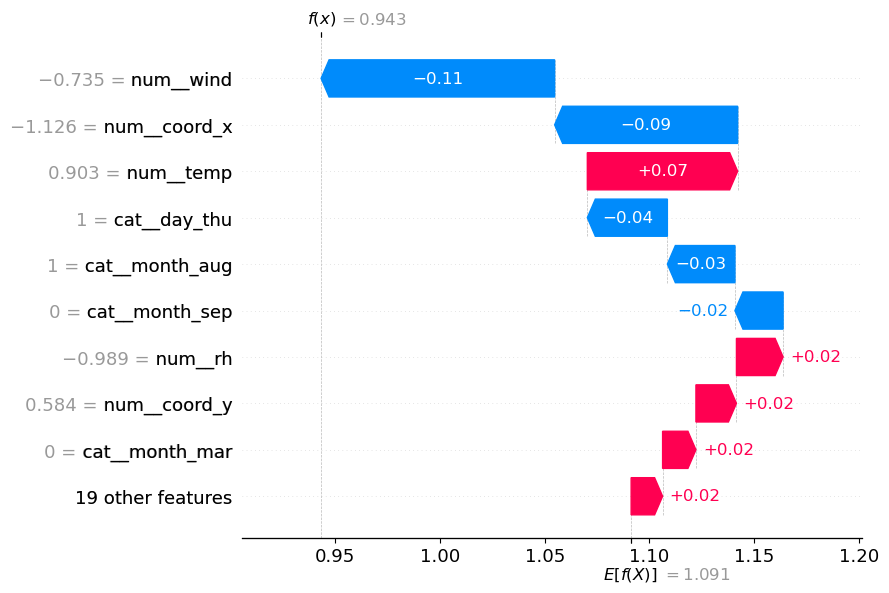

2025-10-04 14:32:47,825, 3185425253.py, 23, INFO, Generated SHAP explanations for the best model using a test instance.


In [21]:
# SHAP explanations for the best model (assumed to be linear for Ridge)

# Preprocessing test data only
X_test_transformed = pipe.named_steps['preproc'].transform(X_test)

# Getting feature names after preprocessing
feature_names = pipe.named_steps['preproc'].get_feature_names_out()

# Creating SHAP explainer for linear model
explainer = shap.explainers.Linear(pipe.named_steps['clf'], X_test_transformed, feature_names=feature_names)

# Choosing one instance to explain (e.g., first row of test set)
instance = X_test.iloc[[0]]
instance_transformed = pipe.named_steps['preproc'].transform(instance)

# Explaining that instance
shap_values_instance = explainer(instance_transformed)

# Ploting the explanation
shap.plots.waterfall(shap_values_instance[0])

# Log the SHAP explanation generation.
_logs.info("Generated SHAP explanations for the best model using a test instance." )

    

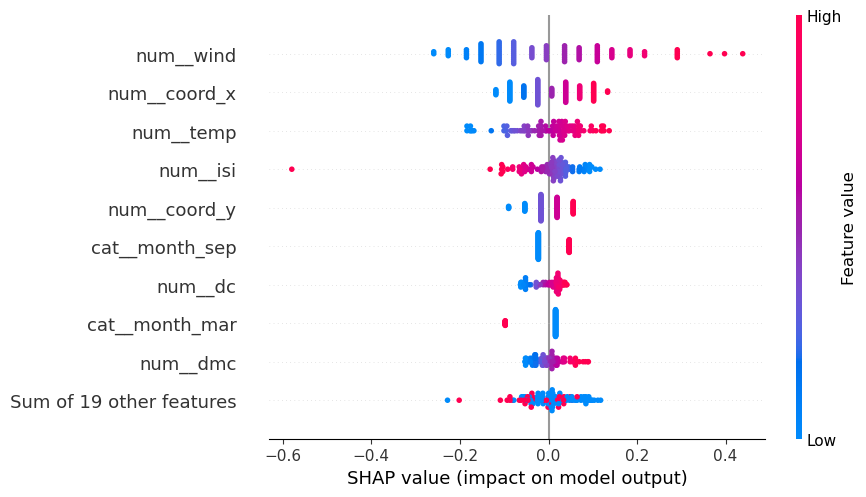

2025-10-04 14:32:48,347, 2079629016.py, 8, INFO, Generated SHAP summary plot for the test set.


In [22]:
# Computing SHAP values for the full test set
shap_values_all = explainer(X_test_transformed)

# Plotting the SHAP summary (beeswarm)
shap.plots.beeswarm(shap_values_all)

# Log the SHAP summary plot generation.
_logs.info("Generated SHAP summary plot for the test set." )


Which features to consider removing? Features with low SHAP contributions. There are 20 other features with very low SHAP values can be removed provided the RMSE doesn't worsen.


## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.